In [50]:
import os
import random
from datetime import datetime

import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [51]:
# Declare  variables, working directory and dataset directory
MODE = 'reduced_features'
NUM_EPOCHS = 100
START_EPOCH = 0
NUM_ITEMS = 1_000_000
BATCH_SIZE = 128
DROPOUT_RATE = 0.5

WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank'
DATASET_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/dataset'

MODEL_MODE = "do" # regular (reg), dropout (do), dropout + l1l2 (dol1l2)
PREFIX = f"{MODEL_MODE}-lrscheduler-{DROPOUT_RATE}"
SUFFIX = f"{NUM_ITEMS}-{NUM_EPOCHS}-{BATCH_SIZE}"
CHECKPOINT_NAME = os.path.join(WORKING_DIR, 'output', 'model', MODE, f'{PREFIX}-checkpoint-{SUFFIX}.pt')

INPUT_SIZE = 40000

print(CHECKPOINT_NAME)

/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/output/model/reduced_features/do-lrscheduler-0.5-checkpoint-1000000-100-256.pt


In [52]:
def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    if device.type == "cuda":
        print(f"Current CUDA device: {torch.cuda.current_device()}")
        print(f"CUDA device name: {torch.cuda.get_device_name(0)}")

    return device

In [53]:
device = get_device()

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


In [54]:
class HepG2Dataset(Dataset):
    def __init__(self, total_samples, features, indexes):
        self.total_samples = total_samples
        self.features = features
        self.indexes = indexes

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        r1 = random.choice(self.indexes)
        r2 = random.choice(self.indexes)
        
        feature_1 = self.features[r1, 2]
        feature_2 = self.features[r2, 2]
        feature = np.concatenate((feature_1, feature_2), axis=0)
        
        val_1 = self.features[r1, 3]
        val_2 = self.features[r2, 3]
        
        y = 1 if val_1 > val_2 else 0
        
        return feature, y

In [55]:
class BinaryClassifier(nn.Module):
    def __init__(self, input_size, hidden1_size=64, hidden2_size=32, output_size=1):
        super(BinaryClassifier, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1_size),
            nn.ReLU(),
            nn.Linear(hidden1_size, hidden2_size),
            nn.ReLU(),
            nn.Linear(hidden2_size, output_size),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x = x.squeeze(1)
        return self.network(x)

    def predict(self, x):
        with torch.no_grad():
            outputs = self.forward(x)
            return (outputs >= 0.5).long()

In [56]:
class BinaryClassifierDropOut(nn.Module):
    def __init__(self, input_size, hidden1_size=64, hidden2_size=32, output_size=1, dropout_rate=0.2):
        super(BinaryClassifierDropOut, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden1_size, hidden2_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden2_size, output_size),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x = x.squeeze(1)
        return self.network(x)

    def predict(self, x):
        with torch.no_grad():
            outputs = self.forward(x)
            return (outputs >= 0.5).long()

In [57]:
class BinaryClassifierDropOutL1L2(nn.Module):
    def __init__(self, input_size, hidden1_size=64, hidden2_size=32, output_size=1, dropout_rate=0.2, l1_lambda=0.001, l2_lambda=0.001):
        super(BinaryClassifierDropOutL1L2, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden1_size, hidden2_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden2_size, output_size),
            nn.Sigmoid()
        )

        self.l1_lambda = l1_lambda
        self.l2_lambda = l2_lambda

    def forward(self, x):
        # x = x.squeeze(1)
        outputs = self.network(x)
        l1_reg = torch.tensor(0., requires_grad=True)
        l2_reg = torch.tensor(0., requires_grad=True)

        for name, param in self.named_parameters():
            if 'weight' in name:
                l1_reg = l1_reg + torch.linalg.norm(param, 1)
                l2_reg = l2_reg + torch.linalg.norm(param, 2)

        return outputs, self.l1_lambda * l1_reg, self.l2_lambda * l2_reg

    def predict(self, x):
        with torch.no_grad():
            outputs, _, _ = self.forward(x)
            return (outputs >= 0.5).long()

In [58]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, num_items):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 6))
    
    # Plot for training and validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'blue', label='Training Loss')
    plt.plot(epochs, val_losses, 'orange', label='Validation Loss')
    plt.title(f'Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.ylim(0.4, 0.8)
    plt.legend()
    plt.grid(True)
    
    # Plot for training and validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'blue', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'orange', label='Validation Accuracy')
    plt.title(f'Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.ylim(50, 90)
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()

    img_name = f"{PREFIX}-ranking-{SUFFIX}.png"
    plt.savefig(os.path.join(WORKING_DIR, 'output', 'img', 'train', MODE, img_name))
    
    plt.show()

In [59]:
# Load dataset
all_features = pl.read_parquet(os.path.join(DATASET_DIR, 'features', f'{MODE}.parquet'))
all_features

index,gene_id,reduced_features,value_1
u32,str,list[f64],f64
0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0
1,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0
2,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452
3,"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743
4,"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934
…,…,…,…
22149,"""XLOC_030009""","[0.0, 0.0, … 0.0]",0.0
22150,"""XLOC_030012""","[0.0, 0.0, … 0.0]",0.0
22151,"""XLOC_030014""","[0.0, 0.0, … 0.0]",0.0


In [60]:
# Convert to numpy array
all_features_np = all_features.to_numpy()

In [61]:
# Split train, test, validation by index
data_indices = np.arange(len(all_features_np))
print(data_indices)

[    0     1     2 ... 22151 22152 22153]


In [62]:
# First split: 80% train, 20% temporary (for test + validation)
train_idx, temp_idx = train_test_split(
    data_indices, 
    test_size=0.2, 
    random_state=42  # For reproducibility
)

In [63]:
# Second split: Split temp_idx into 50% test and 50% validation
val_idx, test_idx = train_test_split(
    temp_idx, 
    test_size=0.5, 
    random_state=42  # Same random_state for consistency
)

In [64]:
# Result: train_idx (80%), test_idx (10%), val_idx (10%)
print(f"Train indices: {len(train_idx)}")
print(f"Test indices: {len(test_idx)}")
print(f"Validation indices: {len(val_idx)}")

Train indices: 17723
Test indices: 2216
Validation indices: 2215


# Experiments

## Training

In [65]:
# Define the dataset
train_dataset = HepG2Dataset(int(0.8 * NUM_ITEMS), all_features_np, train_idx)
val_dataset = HepG2Dataset(int(0.1 * NUM_ITEMS), all_features_np, val_idx)
test_dataset = HepG2Dataset(int(0.1 * NUM_ITEMS), all_features_np, test_idx)

In [66]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

800000
100000
100000


In [67]:
# Define the dataloader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

In [68]:
# Initialize model
if MODEL_MODE == "reg":
    model = BinaryClassifier(input_size=200).to(device)
elif MODEL_MODE == "do":
    model = BinaryClassifierDropOut(input_size=200, dropout_rate=DROPOUT_RATE).to(device)
elif MODEL_MODE == "dol1l2":
    BinaryClassifierDropOutL1L2(input_size=200).to(device)

# Define loss function for binary classification
criterion = nn.BCELoss()  # Binary Cross Entropy Loss

# Training loop example
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Define learning rate scheduler
scheduler = lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

In [69]:
# Arrays for saving the performance metric
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []
val_precisions = []
val_recalls = []
val_f1_scores = []

In [70]:
# Check if the checkpoint exists
if os.path.exists(CHECKPOINT_NAME):
    checkpoint = torch.load(CHECKPOINT_NAME)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    START_EPOCH = checkpoint['epoch'] + 1
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    train_accuracies = checkpoint['train_accuracies']
    val_accuracies = checkpoint['val_accuracies']
    train_aucs = checkpoint['train_aucs']
    val_aucs = checkpoint['val_aucs']
    val_precisions = checkpoint['val_precisions']
    val_recalls = checkpoint['val_recalls']
    val_f1_scores = checkpoint['val_f1_scores']

    print(f"{CHECKPOINT_NAME} exists. Resuming training from epoch {START_EPOCH}.")
else:
    START_EPOCH = 0

In [71]:
# Training loop
for epoch in range(START_EPOCH, NUM_EPOCHS):
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0
    train_true_labels = []
    train_predicted_labels = []

    # Training phase
    for X_batch, y_batch in train_loader:

        if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
            outputs = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device))
        elif MODEL_MODE == "dol1l2":
            outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        predictions = (outputs.squeeze(1) >= 0.5).long()

        train_loss += loss.item()
        train_correct += (predictions == y_batch.to(device)).sum().item()
        train_total += y_batch.size(0)
        
        train_true_labels.extend(y_batch.cpu().numpy())
        train_predicted_labels.extend(predictions.cpu().numpy())
        
    # Adjust learning rate
    scheduler.step()
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_auc_score = roc_auc_score(train_true_labels, train_predicted_labels)

    train_losses.append(round(avg_train_loss, 4))
    train_accuracies.append(round(train_accuracy, 2))
    train_aucs.append(round(train_auc_score, 2))

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_metric = 0
    val_true_labels = []
    val_predicted_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            
            if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
                outputs = model(X_batch.to(dtype=torch.float32).to(device))
                loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device))
            elif MODEL_MODE == "dol1l2":
                outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
                loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg
            
            predictions = (outputs.squeeze(1) >= 0.5).long()
            
            val_loss += loss.item()
            val_correct += (predictions == y_batch.to(dtype=torch.float32).to(device)).sum().item()
            val_total += y_batch.size(0)
            val_true_labels.extend(y_batch.cpu().numpy())
            val_predicted_labels.extend(predictions.cpu().numpy())
            
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_metric = val_correct / len(val_loader)

        # Calculate precision, recall, and F1-score
        precision, recall, f1_score, _ = precision_recall_fscore_support(
            val_true_labels, 
            val_predicted_labels, 
            average='binary'  # Use macro average for multi-class classification
        )

        val_true_labels = np.array(val_true_labels)
        val_predicted_labels = np.array(val_predicted_labels)
        val_auc_score = roc_auc_score(val_true_labels, val_predicted_labels)

        val_losses.append(round(avg_val_loss, 4))
        val_accuracies.append(round(val_accuracy, 2))
        val_aucs.append(round(val_auc_score, 2))
        val_precisions.append(round(precision, 2))
        val_recalls.append(round(recall, 2))
        val_f1_scores.append(round(f1_score, 2))
    

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] - '
          f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, AUC: {train_auc_score:.2f} '
          f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
          f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
          f'AUC: {val_auc_score:.2f}')
    
    # Save the model
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'train_aucs': train_aucs,
        'val_aucs': val_aucs,
        'val_precisions': val_precisions,
        'val_recalls': val_recalls,
        'val_f1_scores': val_f1_scores,
    }, CHECKPOINT_NAME)

Epoch [1/100] - [TRAIN] Loss: 0.5890, Accuracy: 69.89%, AUC: 0.69 [VAL] Loss: 0.5727, Accuracy: 70.01%, Precision: 0.74, Recall: 0.56, F1-Score: 0.64, AUC: 0.69
Epoch [2/100] - [TRAIN] Loss: 0.5690, Accuracy: 70.83%, AUC: 0.70 [VAL] Loss: 0.5689, Accuracy: 70.50%, Precision: 0.70, Recall: 0.64, F1-Score: 0.67, AUC: 0.70
Epoch [3/100] - [TRAIN] Loss: 0.5656, Accuracy: 70.87%, AUC: 0.70 [VAL] Loss: 0.5693, Accuracy: 70.34%, Precision: 0.72, Recall: 0.60, F1-Score: 0.66, AUC: 0.70
Epoch [4/100] - [TRAIN] Loss: 0.5656, Accuracy: 70.76%, AUC: 0.70 [VAL] Loss: 0.5697, Accuracy: 70.19%, Precision: 0.72, Recall: 0.61, F1-Score: 0.66, AUC: 0.70
Epoch [5/100] - [TRAIN] Loss: 0.5637, Accuracy: 70.82%, AUC: 0.70 [VAL] Loss: 0.5696, Accuracy: 70.23%, Precision: 0.74, Recall: 0.57, F1-Score: 0.64, AUC: 0.70
Epoch [6/100] - [TRAIN] Loss: 0.5624, Accuracy: 70.91%, AUC: 0.70 [VAL] Loss: 0.5687, Accuracy: 70.27%, Precision: 0.72, Recall: 0.60, F1-Score: 0.65, AUC: 0.70
Epoch [7/100] - [TRAIN] Loss: 0.56

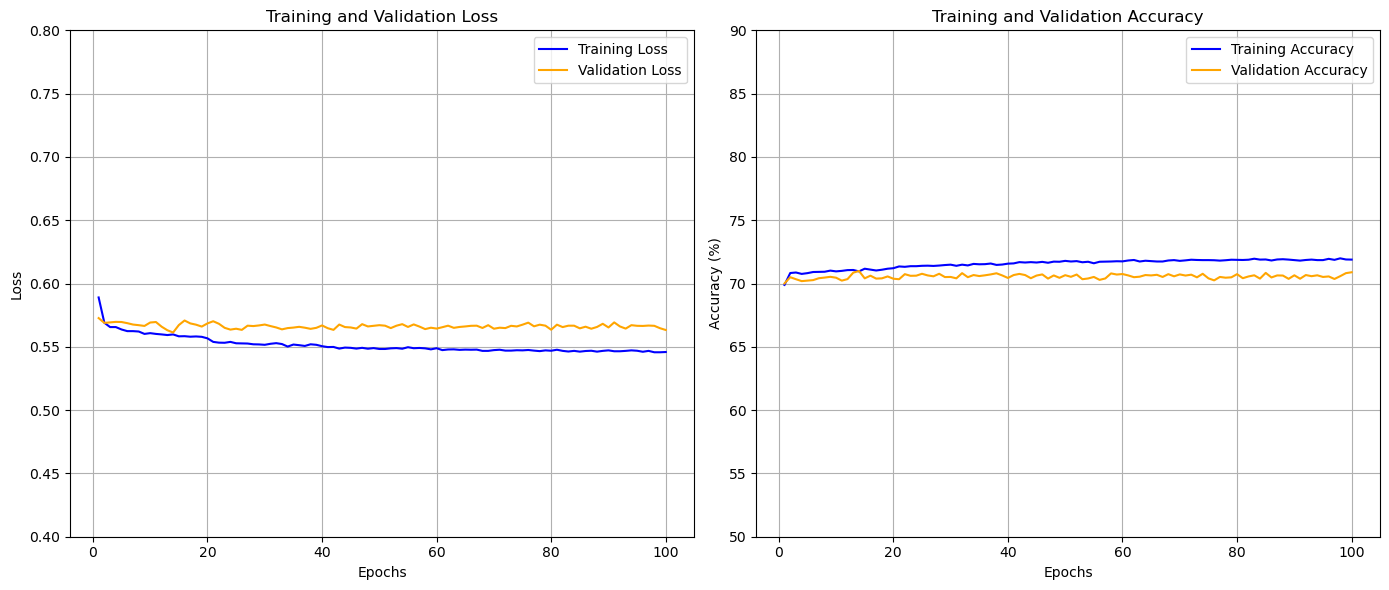

In [72]:
plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, NUM_ITEMS)

## Testing

In [73]:
# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch.to(dtype=torch.float32).to(device))
        predictions = (outputs.squeeze(1) >= 0.5).long()
        test_true_labels.extend(y_batch.cpu().numpy())
        test_predictions.extend(predictions.cpu().numpy())

In [74]:
# Evaluation metrics
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='binary'  # Use 'macro' for multi-class
)

test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
test_auc_score = roc_auc_score(test_true_labels, test_predictions)
cr = classification_report(test_true_labels, test_predictions)
cm = confusion_matrix(test_true_labels, test_predictions)

In [75]:
test_output = f"""Accuracy Score on test set: {test_acc_score:.2f} %
AUC Score on test set: {test_auc_score:.2f}
Precision: {precision:.4f}
Recall: {recall:.4f}
F1-Score: {f1_score:.4f}

Detailed Classification Report:
{cr}

Confusion Matrix:
{cm}
"""

print(test_output)

Accuracy Score on test set: 70.21 %
AUC Score on test set: 0.70
Precision: 0.7196
Recall: 0.6128
F1-Score: 0.6619

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.78      0.73     52405
           1       0.72      0.61      0.66     47595

    accuracy                           0.70    100000
   macro avg       0.70      0.70      0.70    100000
weighted avg       0.70      0.70      0.70    100000


Confusion Matrix:
[[41040 11365]
 [18427 29168]]



In [76]:
# Save the test output to text file
test_file_name = os.path.join(WORKING_DIR, 'output', 'test', MODE, f"{PREFIX}-test-results-{SUFFIX}.txt")
with open(test_file_name, 'w', newline = '') as text_file:
    text_file.write(test_output)

# Saving all metrics

In [77]:
# Training metrics
file_name = f"{PREFIX}-train-validation-metrics-{SUFFIX}.csv"
result_file = os.path.join(WORKING_DIR, 'output', 'train', MODE, f"{file_name}")

experiment_results = {
    'train_loss'    : train_losses,
    'train_accuracy': train_accuracies,
    'train_auc'     : train_aucs,
    'val_loss'      : val_losses,
    'val_accuracy'  : val_accuracies,
    'val_auc'       : val_aucs
}

experiment_pl = pl.DataFrame(experiment_results)
experiment_pl.write_csv(result_file)

In [78]:
# Test output
test_name = f"{PREFIX}-test-metrics-{SUFFIX}.csv"
test_file = os.path.join(WORKING_DIR, 'output', 'test', MODE,f"{test_name}")

test_results = {
    'test_acc'    : round(test_acc_score, 4),
    'test_auc'    : round(test_auc_score, 4)
}

test_pl = pl.DataFrame(test_results)
test_pl.write_csv(test_file)

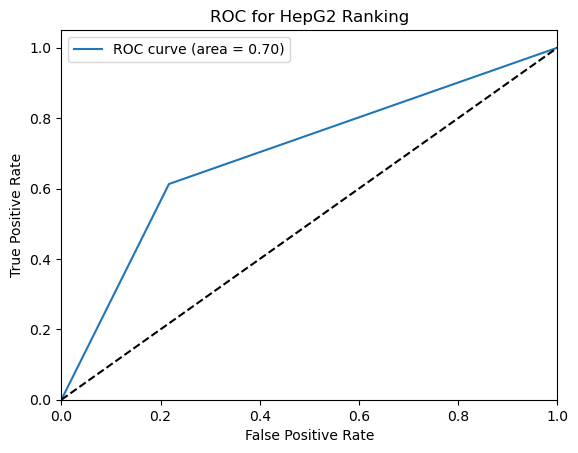

In [79]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_true_labels, test_predictions) 
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC for HepG2 Ranking')
plt.legend()

img_name = f"{PREFIX}-roc-{SUFFIX}.png"
plt.savefig(os.path.join(WORKING_DIR, 'output', 'img', 'roc', MODE, img_name))

plt.show()

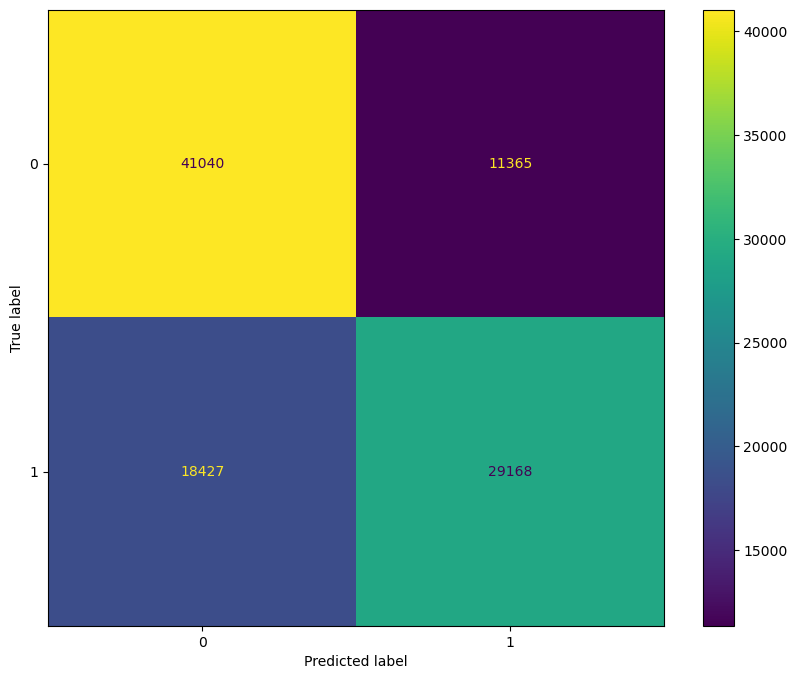

In [80]:
# Plot the confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 8))
cm_display.plot(ax=ax)
img_name = f"{PREFIX}-cm-{SUFFIX}.png"
plt.savefig(os.path.join(WORKING_DIR, 'output', 'img', 'confusion_matrix', MODE, img_name))